## Alexander Rees
## Andrew Lotocki
## Project Phase I
## DS 4420


# Scrape Data From CFB and Kaggle

In [2]:
!{sys.executable} -m pip install --upgrade kagglehub requests
!pip install pandas==2.2.2 numpy==1.26.4 requests==2.32.4 --force-reinstall
!pip install rapidfuzz

  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
Using cached requests-2.33.1-py3-none-any.whl (64 kB)
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tz

  Using cached rapidfuzz-3.14.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (12 kB)
Using cached rapidfuzz-3.14.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (3.2 MB)


In [215]:
import sys
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import re
import requests
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from rapidfuzz import process, fuzz
from keras.models import Model
from keras.layers import Dense, Input, SimpleRNN
from keras.optimizers import SGD
from keras.losses import binary_crossentropy
import numpy as np
from dotenv import load_dotenv
import os

In [5]:
load_dotenv()
combine_file = 'nfl_combine_2010_to_2023.csv'
CFB_API_KEY = os.getenv("API_KEY")
headers = {"Authorization": f"Bearer {CFB_API_KEY}"}
years = list(range(2008, 2024))
combine_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, 'thomassshaw/nfl-combine-performance-dataset', path=combine_file)


def clean_name(name):
    if pd.isna(name):
        return None
    name = name.lower()
    name = re.sub(r"[^\w\s]", "", name)
    name = re.sub(r"\b(jr|sr|ii|iii|iv|v)\b", "", name)
    name = re.sub(r"\s+", " ", name)
    return name.strip()

position_map = {
    "wide receiver": "WR", "wr": "WR",
    "running back": "RB", "rb": "RB",
    "quarterback": "QB", "qb": "QB",
    "tight end": "TE", "te": "TE",
    "cornerback": "CB", "cb": "CB",
    "safety": "S", "s": "S",
    "linebacker": "LB", "lb": "LB",
    "defensive line": "DL", "dl": "DL",
    "defensive tackle": "DT", "dt": "DT",
    "defensive end": "DE", "de": "DE",
    "offensive line": "OL", "ol": "OL"
}

def clean_position(pos):
    if pd.isna(pos):
        return None
    pos = str(pos).lower().strip()
    return position_map.get(pos, pos.upper())

combine_df["clean_name"] = combine_df["Player"].apply(clean_name)
combine_df["position_clean"] = combine_df["Pos"].apply(clean_position)
combine_df["draft_year"] = combine_df["Year"]
cfb_list = []

for year in years:
    url = f"https://api.collegefootballdata.com/stats/player/season?year={year}"
    r = requests.get(url, headers=headers)
    data = r.json()

    if len(data) == 0:
        continue

    df = pd.DataFrame(data)
    df["clean_name"] = df["player"].apply(clean_name)
    df["position_clean"] = df["position"].apply(clean_position)
    df["season"] = year
    cfb_list.append(df)

cfb_df = pd.concat(cfb_list, ignore_index=True)
cfb_df["stat"] = cfb_df["stat"].astype(str)
cfb_df["stat"] = cfb_df["stat"].str.split("-").str[0]
cfb_df["stat"] = pd.to_numeric(cfb_df["stat"], errors="coerce")
cfb_df = cfb_df[cfb_df["stat"] < 10000]
last_season = cfb_df.groupby("clean_name")["season"].max().reset_index()
cfb_df = pd.merge(cfb_df, last_season, on=["clean_name", "season"], how="inner")

cfb_wide = cfb_df.pivot_table(
    index=["clean_name", "season", "position_clean"],
    columns=["category", "statType"],
    values="stat",
    aggfunc="sum"
).reset_index()

cfb_wide.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in cfb_wide.columns
]

cfb_wide.columns.name = None

cfb_by_position = {
    pos: group["clean_name"].dropna().values
    for pos, group in cfb_wide.groupby("position_clean")
}

all_cfb_names = cfb_wide["clean_name"].dropna().values


def match_with_position(name, pos, threshold=88):
    if pd.isna(name):
        return None, 0

    choices = cfb_by_position.get(pos)
    if choices is None or len(choices) == 0:
        choices = all_cfb_names

    match = process.extractOne(
        name,
        choices,
        scorer=fuzz.token_sort_ratio)

    if match is None:
        return None, 0

    matched_name, score, _ = match

    if score >= threshold:
        return matched_name, score
    else:
        return None, score


matches = combine_df.apply(lambda row: match_with_position(row["clean_name"], row["position_clean"]), axis=1)

combine_df["matched_name"] = matches.apply(lambda x: x[0])
combine_df["match_score"] = matches.apply(lambda x: x[1])

merged_df = pd.merge(
    combine_df,
    cfb_wide,
    left_on="matched_name",
    right_on="clean_name",
    how="left",
    suffixes=("", "_cfb")
)


merged_df = merged_df[(merged_df["season"] >= merged_df["Year"] - 2) & (merged_df["season"] <= merged_df["Year"])]

merged_df = merged_df.sort_values("match_score", ascending=False)
merged_df = merged_df.drop_duplicates(subset=["Player", "Year"])
merged_df.to_csv("data/player_data.csv", index=False)

print("Match rate:", combine_df["matched_name"].notna().mean())
print(merged_df.head())

Using Colab cache for faster access to the 'nfl-combine-performance-dataset' dataset.
Match rate: 0.5292132461506012
      Year           Player Pos          School Height  Weight  40yd  \
0     2010   Seyi Ajirotutu  WR    Fresno State    6-3   204.0  4.60   
3582  2020     Josiah Scott  CB  Michigan State    5-9   185.0  4.42   
3563  2020  Michael Pittman  WR             USC    6-4   223.0  4.52   
3564  2020       Troy Pride  CB      Notre Dame   5-11   193.0  4.40   
3565  2020     James Proche  WR             SMU   5-11   201.0   NaN   

      Vertical  Bench  Broad Jump  ...  receiving_LONG  receiving_REC  \
0         36.0   14.0       115.0  ...            46.0           49.0   
3582       NaN   17.0         NaN  ...             NaN            NaN   
3563      36.5   13.0       121.0  ...            77.0          101.0   
3564      35.5   13.0       119.0  ...             NaN            NaN   
3565      34.5   20.0         NaN  ...            52.0          111.0   

      recei

# Seperating Cleaning and Scaling our Data

In [62]:
df = pd.read_csv("data/player_data.csv")
df = df.drop(columns=['season', 'Year', 'clean_name', 'Round', 'School', 'clean_name_cfb','match_score','position_clean_cfb', 'position_clean', 'matched_name'])
df["Height"] = (df["Height"].astype(str).str.split("-").apply(lambda x: int(x[0]) * 12 + int(x[1]) if len(x) == 2 else None))
df["Drafted"] = df["Drafted"].fillna(0).astype(int)
cols = [c for c in df.columns if c not in ["Player", "Pos"]]
df[cols] = df[cols].astype(float)

qb_data = df[df["Pos"] == "QB"]
qb_data = qb_data.dropna(axis=1, thresh=len(qb_data) * 0.5).reset_index(drop=True)
qb_data = qb_data.fillna(0)

rb_data = df[df["Pos"] == "RB"]
rb_data = rb_data.dropna(axis=1, thresh=len(rb_data) * 0.5).reset_index(drop=True)
rb_data = rb_data.fillna(0)

cb_data = df[df["Pos"] == "CB"]
cb_data = cb_data.dropna(axis=1, thresh=len(cb_data) * 0.5).reset_index(drop=True)
cb_data = cb_data.fillna(0)

wr_data = df[df["Pos"] == "WR"]
wr_data = wr_data.dropna(axis=1, thresh=len(wr_data) * 0.5).reset_index(drop=True)
wr_data = wr_data.fillna(0)

de_data = df[df["Pos"] == "DE"]
de_data = de_data.dropna(axis=1, thresh=len(de_data) * 0.5).reset_index(drop=True)
de_data = de_data.fillna(0)

qb_data.to_csv("data/qb_data.csv", index=False)
rb_data.to_csv("data/rb_data.csv", index=False)
cb_data.to_csv("data/cb_data.csv", index=False)
wr_data.to_csv("data/wr_data.csv", index=False)
de_data.to_csv("data/de_data.csv", index=False)

In [63]:
print(qb_data.shape)
print(qb_data.columns)
qb_data.head()

(212, 24)
Index(['Player', 'Pos', 'Height', 'Weight', '40yd', 'Vertical', 'Broad Jump',
       '3Cone', 'Shuttle', 'Drafted', 'Pick', 'draft_year', 'passing_ATT',
       'passing_COMPLETIONS', 'passing_INT', 'passing_PCT', 'passing_TD',
       'passing_YDS', 'passing_YPA', 'rushing_CAR', 'rushing_LONG',
       'rushing_TD', 'rushing_YDS', 'rushing_YPC'],
      dtype='object')


,Player,Pos,Height,Weight,40yd,Vertical,Broad Jump,3Cone,Shuttle,Drafted,...,passing_INT,passing_PCT,passing_TD,passing_YDS,passing_YPA,rushing_CAR,rushing_LONG,rushing_TD,rushing_YDS,rushing_YPC
0,Shea Patterson,QB,73.0,212.0,4.71,31.0,116.0,7.14,4.50,0.0,...,8.0,0.562,23.0,3061.0,8.0,87.0,22.0,5.0,50.0,0.6
1,Tua Tagovailoa,QB,72.0,217.0,0.00,0.0,0.0,0.00,0.00,1.0,...,3.0,0.714,33.0,2840.0,11.3,23.0,25.0,2.0,17.0,0.7
2,Jalen Hurts,QB,73.0,222.0,4.59,35.0,125.0,0.00,0.00,1.0,...,8.0,0.695,32.0,3851.0,11.3,233.0,52.0,20.0,1298.0,5.6
3,Anthony Gordon,QB,74.0,205.0,0.00,0.0,0.0,0.00,0.00,0.0,...,16.0,0.716,48.0,5575.0,8.1,51.0,17.0,0.0,0.0,0.0
4,Justin Herbert,QB,78.0,236.0,4.68,35.5,123.0,7.06,4.46,1.0,...,6.0,0.668,32.0,3471.0,8.1,58.0,30.0,4.0,50.0,0.9


In [64]:
print(rb_data.shape)
print(rb_data.columns)
rb_data.head()

(338, 23)
Index(['Player', 'Pos', 'Height', 'Weight', '40yd', 'Vertical', 'Bench',
       'Broad Jump', '3Cone', 'Shuttle', 'Drafted', 'Pick', 'draft_year',
       'receiving_LONG', 'receiving_REC', 'receiving_TD', 'receiving_YDS',
       'receiving_YPR', 'rushing_CAR', 'rushing_LONG', 'rushing_TD',
       'rushing_YDS', 'rushing_YPC'],
      dtype='object')


,Player,Pos,Height,Weight,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,...,receiving_LONG,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_CAR,rushing_LONG,rushing_TD,rushing_YDS,rushing_YPC
0,James Robinson,RB,69.0,219.0,4.64,40.0,24.0,125.0,7.03,4.19,...,12.0,2.0,0.0,10.0,5.0,13.0,18.0,0.0,16.0,1.2
1,Sewo Olonilua,RB,75.0,232.0,4.66,36.0,25.0,123.0,0.00,4.28,...,19.0,24.0,1.0,114.0,4.8,134.0,35.0,8.0,537.0,4.0
2,La'Mical Perine,RB,71.0,216.0,4.62,35.0,22.0,118.0,7.13,4.31,...,30.0,40.0,5.0,262.0,6.6,132.0,88.0,6.0,676.0,5.1
3,Scottie Phillips,RB,68.0,209.0,4.56,30.0,29.0,114.0,7.40,4.53,...,22.0,8.0,1.0,77.0,9.6,125.0,38.0,5.0,542.0,4.3
4,Ke'Shawn Vaughn,RB,70.0,214.0,4.51,32.0,0.0,117.0,0.00,0.00,...,61.0,28.0,1.0,270.0,9.6,198.0,75.0,9.0,1028.0,5.2


In [65]:
print(cb_data.shape)
print(cb_data.columns)
cb_data.head()

(211, 24)
Index(['Player', 'Pos', 'Height', 'Weight', '40yd', 'Vertical', 'Bench',
       'Broad Jump', '3Cone', 'Shuttle', 'Drafted', 'Pick', 'draft_year',
       'defensive_PD', 'defensive_QB HUR', 'defensive_SACKS', 'defensive_SOLO',
       'defensive_TD', 'defensive_TFL', 'defensive_TOT', 'interceptions_AVG',
       'interceptions_INT', 'interceptions_TD', 'interceptions_YDS'],
      dtype='object')


,Player,Pos,Height,Weight,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,...,defensive_QB HUR,defensive_SACKS,defensive_SOLO,defensive_TD,defensive_TFL,defensive_TOT,interceptions_AVG,interceptions_INT,interceptions_TD,interceptions_YDS
0,Josiah Scott,CB,69.0,185.0,4.42,0.0,17.0,0.0,0.00,0.00,...,0.0,0.0,38.0,0.0,0.0,55.0,11.3,3.0,0.0,34.0
1,Troy Pride,CB,71.0,193.0,4.40,35.5,13.0,119.0,6.94,4.26,...,0.0,0.0,27.0,0.0,0.0,40.0,39.0,1.0,0.0,39.0
2,John Reid,CB,70.0,187.0,4.49,36.5,20.0,129.0,6.95,3.97,...,1.0,1.0,26.0,1.0,2.5,37.0,30.5,2.0,1.0,61.0
3,Amik Robertson,CB,68.0,187.0,0.00,0.0,0.0,0.0,0.00,0.00,...,1.0,1.0,44.0,3.0,8.0,60.0,19.4,5.0,2.0,97.0
4,James Pierre,CB,72.0,183.0,4.59,33.5,0.0,123.0,7.02,0.00,...,0.0,0.0,30.0,0.0,4.5,43.0,11.0,3.0,0.0,33.0


In [66]:
print(wr_data.shape)
print(wr_data.columns)
wr_data.head()

(558, 23)
Index(['Player', 'Pos', 'Height', 'Weight', '40yd', 'Vertical', 'Bench',
       'Broad Jump', '3Cone', 'Shuttle', 'Drafted', 'Pick', 'draft_year',
       'receiving_LONG', 'receiving_REC', 'receiving_TD', 'receiving_YDS',
       'receiving_YPR', 'rushing_CAR', 'rushing_LONG', 'rushing_TD',
       'rushing_YDS', 'rushing_YPC'],
      dtype='object')


,Player,Pos,Height,Weight,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,...,receiving_LONG,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_CAR,rushing_LONG,rushing_TD,rushing_YDS,rushing_YPC
0,Seyi Ajirotutu,WR,75.0,204.0,4.60,36.0,14.0,115.0,7.22,4.39,...,46.0,49.0,7.0,677.0,13.8,0.0,0.0,0.0,0.0,0.0
1,Michael Pittman,WR,76.0,223.0,4.52,36.5,13.0,121.0,6.96,4.14,...,77.0,101.0,11.0,1275.0,12.6,0.0,0.0,0.0,0.0,0.0
2,James Proche,WR,71.0,201.0,0.00,34.5,20.0,0.0,7.27,4.40,...,52.0,111.0,15.0,1225.0,11.0,4.0,12.0,0.0,18.0,4.5
3,Jalen Reagor,WR,71.0,206.0,4.47,42.0,17.0,138.0,7.31,4.46,...,55.0,43.0,5.0,611.0,14.2,14.0,29.0,0.0,89.0,6.4
4,Joe Reed,WR,72.0,224.0,4.47,38.0,21.0,123.0,0.00,0.00,...,43.0,77.0,7.0,679.0,8.8,8.0,22.0,0.0,42.0,5.3


In [67]:
print(de_data.shape)
print(de_data.columns)
de_data.head()

(71, 20)
Index(['Player', 'Pos', 'Height', 'Weight', '40yd', 'Vertical', 'Bench',
       'Broad Jump', '3Cone', 'Shuttle', 'Drafted', 'Pick', 'draft_year',
       'defensive_PD', 'defensive_QB HUR', 'defensive_SACKS', 'defensive_SOLO',
       'defensive_TD', 'defensive_TFL', 'defensive_TOT'],
      dtype='object')


,Player,Pos,Height,Weight,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Drafted,Pick,draft_year,defensive_PD,defensive_QB HUR,defensive_SACKS,defensive_SOLO,defensive_TD,defensive_TFL,defensive_TOT
0,Victor Dimukeje,DE,73.0,262.0,4.87,34.5,28.0,115.0,7.25,4.35,1.0,210.0,2021.0,1.0,2.0,7.5,22.0,0.0,8.0,39.0
1,Jonathon Cooper,DE,74.0,253.0,4.69,33.0,28.0,108.0,6.99,4.31,1.0,239.0,2021.0,1.0,2.0,3.5,12.0,0.0,3.5,24.0
2,Kentavius Street,DE,74.0,280.0,4.87,0.0,28.0,0.0,0.00,0.00,1.0,128.0,2018.0,2.0,4.0,3.5,16.0,0.0,6.5,38.0
3,Joshua Paschal,DE,75.0,268.0,4.77,37.5,0.0,123.0,0.00,0.00,1.0,46.0,2022.0,0.0,8.0,5.0,24.0,0.0,15.0,52.0
4,Colby Wooden,DE,76.0,273.0,4.79,0.0,23.0,115.0,0.00,4.52,1.0,116.0,2023.0,3.0,10.0,6.0,36.0,0.0,11.5,45.0


# Building Our MPL Draft Prediction Models

### QB Model

In [294]:
qb_df = pd.read_csv("data/qb_data.csv")
y_qb = qb_df["Drafted"].to_numpy()

X_qb = qb_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_qb = MinMaxScaler().fit_transform(X_qb)

X_train, X_test, y_train, y_test = train_test_split(X_qb, y_qb, test_size=0.2, random_state=42)

In [295]:
inpx = Input(shape=(X_train.shape[1], 1))
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=30, class_weight=class_weight_dict)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4260 - loss: 0.6909  
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4379 - loss: 0.6901
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4793 - loss: 0.6880 
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5030 - loss: 0.6871 
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5089 - loss: 0.6866  
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4615 - loss: 0.6851 
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4615 - loss: 0.6844 
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5030 - loss: 0.6832
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5325 - loss: 0.6820
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5503 - loss: 0.6808
Epoch 11/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5562 - loss: 0.6799
Epoch 12/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5266 - loss: 0.6787

In [296]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.686
accuracy= 0.512


In [297]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Actual     0   1
Predicted       
0          7  12
1          9  15


In [298]:
feature_cols = qb_df.drop(columns=["Player", "Pos", "Drafted", "Pick"]).columns.tolist()
dense_weights = model.get_layer(index=3).get_weights()[0]
feature_importance = dense_weights.mean(axis=1)

for name, score in sorted(zip(feature_cols, feature_importance), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

rushing_LONG: 0.2180
passing_YDS: 0.2149
passing_PCT: 0.1716
Height: 0.1016
passing_INT: 0.1012
Shuttle: 0.0566
passing_COMPLETIONS: 0.0273
Broad Jump: 0.0045
rushing_YPC: -0.0339
draft_year: -0.0445
3Cone: -0.0604
passing_TD: -0.0634
rushing_TD: -0.0684
rushing_YDS: -0.0798
40yd: -0.0886
rushing_CAR: -0.0957
passing_ATT: -0.1232
Vertical: -0.1382
passing_YPA: -0.1562
Weight: -0.2115


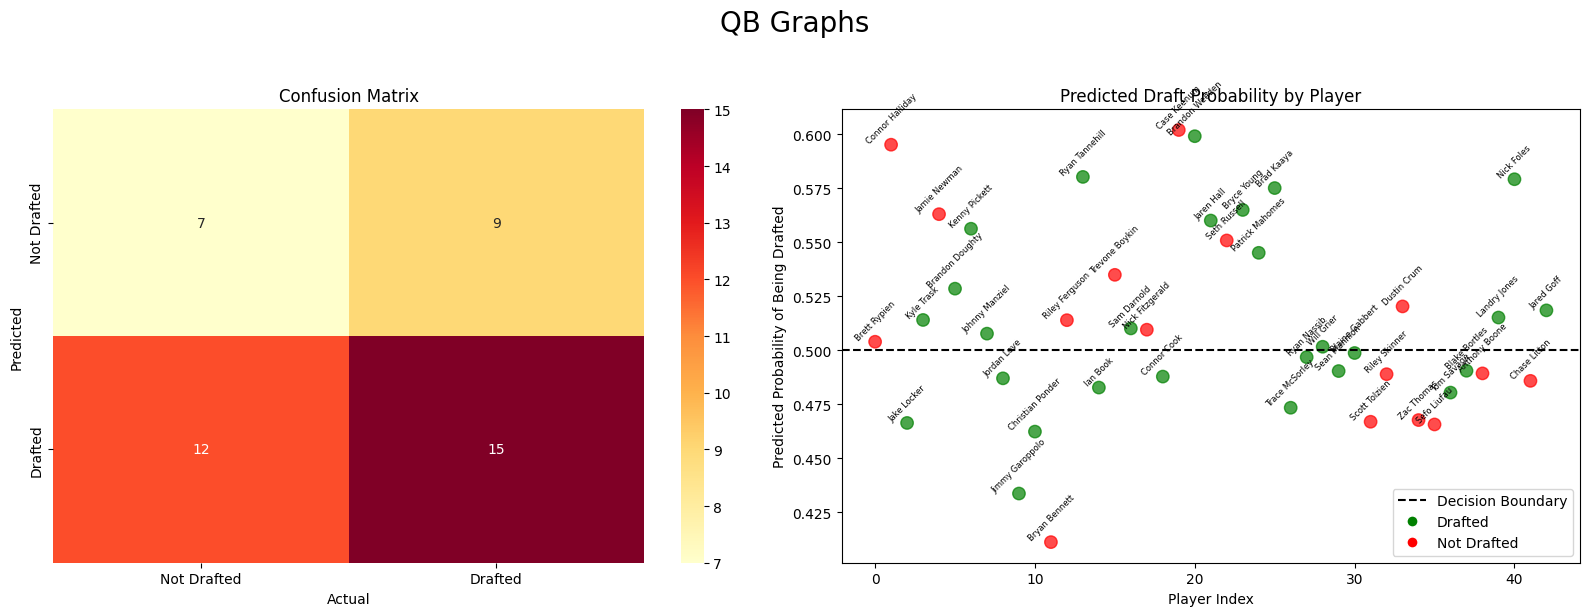

In [299]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('QB Graphs', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

_, X_test_raw, _, y_test_raw, _, names_test = train_test_split(
    X_qb, y_qb, qb_df["Player"].values, test_size=0.2, random_state=42
)

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    axes[1].annotate(name, (i, preds_flat[i]), fontsize=6, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### RB Model

In [288]:
rb_df = pd.read_csv("data/rb_data.csv")
y_rb = rb_df["Drafted"].to_numpy()

X_rb = rb_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_rb = MinMaxScaler().fit_transform(X_rb)

X_train, X_test, y_train, y_test = train_test_split(X_rb, y_rb, test_size=0.2, random_state=42)

In [289]:
inpx = Input(shape=(X_train.shape[1], 1))
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=30, class_weight=class_weight_dict)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5593 - loss: 0.6948  
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5630 - loss: 0.6921 
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5593 - loss: 0.6902 
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5556 - loss: 0.6886 
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5667 - loss: 0.6872 
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5852 - loss: 0.6859 
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5815 - loss: 0.6845 
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5926 - loss: 0.6832 
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5852 - loss: 0.6823 
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6037 - loss: 0.6812 
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6185 - loss: 0.6798 
Epoch 12/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6296 - loss: 0.6787 


In [290]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.668
accuracy= 0.603


In [291]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Actual      0   1
Predicted        
0           9  15
1          12  32


In [292]:
feature_cols = rb_df.drop(columns=["Player", "Pos", "Drafted", "Pick"]).columns.tolist()
dense_weights = model.get_layer(index=3).get_weights()[0]
feature_importance = dense_weights.mean(axis=1)

for name, score in sorted(zip(feature_cols, feature_importance), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

receiving_YPR: 0.1849
receiving_YDS: 0.1720
receiving_REC: 0.1520
Shuttle: 0.1121
draft_year: 0.0958
rushing_YPC: 0.0812
Height: 0.0705
receiving_TD: 0.0379
Vertical: 0.0154
3Cone: -0.0146
Weight: -0.0298
40yd: -0.0483
Broad Jump: -0.1020
Bench: -0.1028
rushing_TD: -0.1106
receiving_LONG: -0.1123
rushing_LONG: -0.1227
rushing_CAR: -0.1365
rushing_YDS: -0.1483


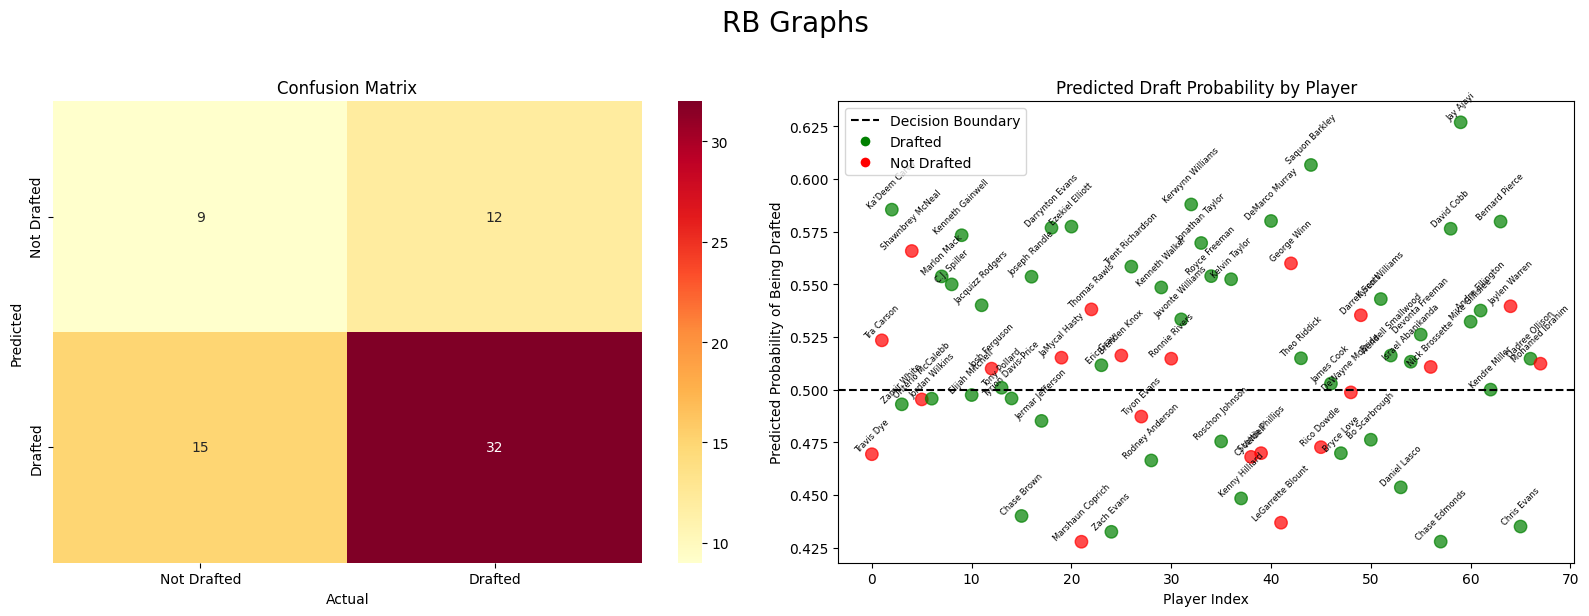

In [293]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RB Graphs', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

_, X_test_raw, _, y_test_raw, _, names_test = train_test_split(
    X_rb, y_rb, rb_df["Player"].values, test_size=0.2, random_state=42
)

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    axes[1].annotate(name, (i, preds_flat[i]), fontsize=6, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### WR Model

In [282]:
wr_df = pd.read_csv("data/wr_data.csv")
y_wr = wr_df["Drafted"].to_numpy()

X_wr = wr_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_wr = MinMaxScaler().fit_transform(X_wr)

X_train, X_test, y_train, y_test = train_test_split(X_wr, y_wr, test_size=0.2, random_state=42)

In [283]:
inpx = Input(shape=(X_train.shape[1], 1))
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=30, class_weight=class_weight_dict)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5874 - loss: 0.6926  
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6099 - loss: 0.6905 
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6413 - loss: 0.6882 
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5762 - loss: 0.6868 
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6323 - loss: 0.6850 
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6323 - loss: 0.6835 
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6525 - loss: 0.6820  
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6570 - loss: 0.6807 
Epoch 9/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6502 - loss: 0.6794 
Epoch 10/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6547 - loss: 0.6778 
Epoch 11/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6906 - loss: 0.6766 
Epoch 12/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [284]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.65
accuracy= 0.67


In [285]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Actual      0   1
Predicted        
0          22  14
1          23  53


In [286]:
feature_cols = wr_df.drop(columns=["Player", "Pos", "Drafted", "Pick"]).columns.tolist()
dense_weights = model.get_layer(index=3).get_weights()[0]
feature_importance = dense_weights.mean(axis=1)

for name, score in sorted(zip(feature_cols, feature_importance), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

Broad Jump: 0.2251
receiving_TD: 0.2080
rushing_TD: 0.1476
Shuttle: 0.1422
rushing_LONG: 0.1191
receiving_REC: 0.1190
receiving_YDS: 0.0914
draft_year: 0.0736
Bench: 0.0332
Height: 0.0193
40yd: 0.0134
rushing_YPC: 0.0122
receiving_LONG: 0.0052
3Cone: -0.0025
rushing_YDS: -0.0206
receiving_YPR: -0.0932
rushing_CAR: -0.0964
Vertical: -0.1570
Weight: -0.1746


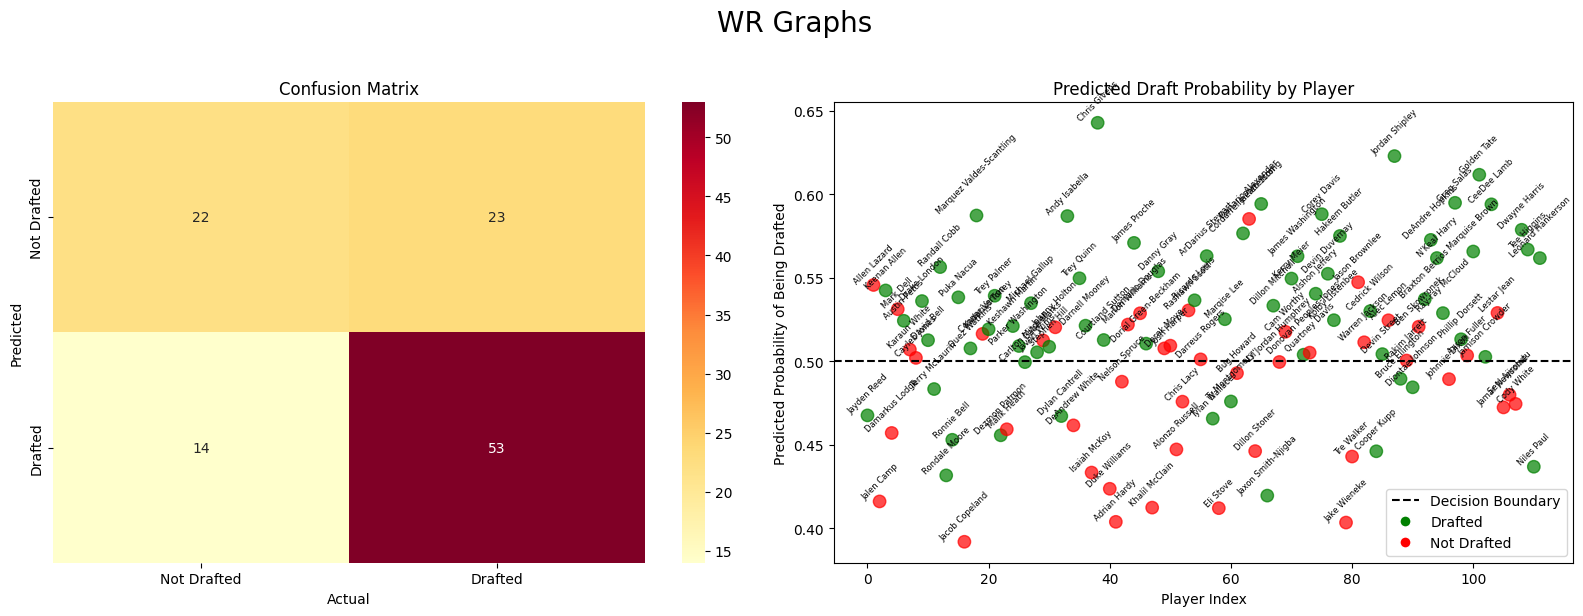

In [287]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('WR Graphs', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

_, X_test_raw, _, y_test_raw, _, names_test = train_test_split(
    X_wr, y_wr, wr_df["Player"].values, test_size=0.2, random_state=42
)

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    axes[1].annotate(name, (i, preds_flat[i]), fontsize=6, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### CB Model

In [276]:
cb_df = pd.read_csv("data/cb_data.csv")
y_cb = cb_df["Drafted"].to_numpy()

X_cb = cb_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_cb = MinMaxScaler().fit_transform(X_cb)

X_train, X_test, y_train, y_test = train_test_split(X_cb, y_cb, test_size=0.2, random_state=42)

In [277]:
inpx = Input(shape=(X_train.shape[1], 1))
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=30, class_weight=class_weight_dict)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3810 - loss: 0.6878  
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4940 - loss: 0.6869 
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4940 - loss: 0.6864  
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5655 - loss: 0.6857 
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4821 - loss: 0.6854  
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5000 - loss: 0.6848  
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.6840 
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6012 - loss: 0.6832 
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6548 - loss: 0.6831 
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6429 - loss: 0.6818 
Epoch 11/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6429 - loss: 0.6815 
Epoch 12/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6845 - loss: 0.680

In [278]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.674
accuracy= 0.698


In [279]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Actual     0   1
Predicted       
0          4   7
1          6  26


In [280]:
feature_cols = cb_df.drop(columns=["Player", "Pos", "Drafted", "Pick"]).columns.tolist()
dense_weights = model.get_layer(index=3).get_weights()[0]
feature_importance = dense_weights.mean(axis=1)

for name, score in sorted(zip(feature_cols, feature_importance), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

Weight: 0.2146
defensive_TFL: 0.1955
defensive_SACKS: 0.1745
defensive_SOLO: 0.1591
defensive_TD: 0.1517
interceptions_AVG: 0.1464
defensive_QB HUR: 0.0549
Shuttle: 0.0419
Height: 0.0228
defensive_TOT: -0.0265
interceptions_TD: -0.0458
Broad Jump: -0.0542
Vertical: -0.0663
Bench: -0.0930
interceptions_YDS: -0.1424
40yd: -0.1526
interceptions_INT: -0.1860
defensive_PD: -0.1920
draft_year: -0.2118
3Cone: -0.2167


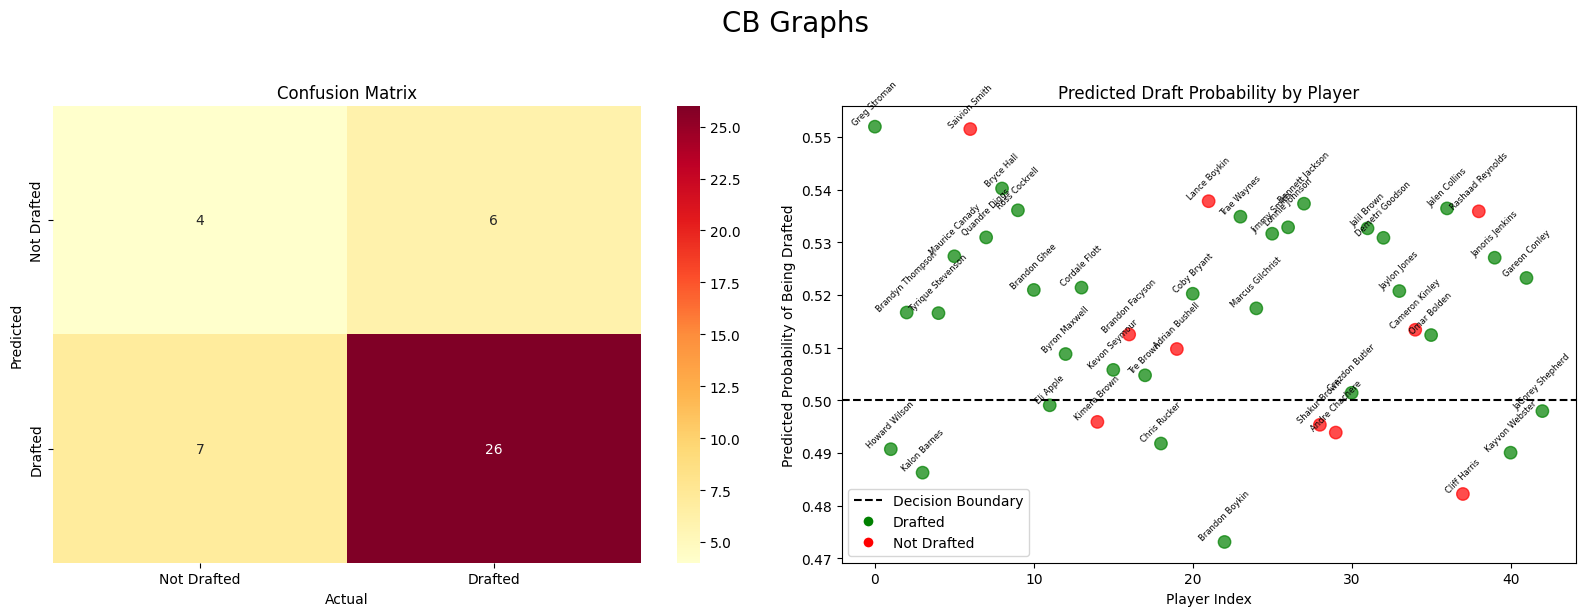

In [281]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CB Graphs', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

_, X_test_raw, _, y_test_raw, _, names_test = train_test_split(
    X_cb, y_cb, cb_df["Player"].values, test_size=0.2, random_state=42
)

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    axes[1].annotate(name, (i, preds_flat[i]), fontsize=6, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### DE Model

In [269]:
de_df = pd.read_csv("data/de_data.csv")
y_de = de_df["Drafted"].to_numpy()

X_de = de_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_de = MinMaxScaler().fit_transform(X_de)

X_train, X_test, y_train, y_test = train_test_split(X_de, y_de, test_size=0.2, random_state=42)

In [270]:
inpx = Input(shape=(X_train.shape[1], 1))
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=30, class_weight=class_weight_dict)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6429 - loss: 0.6941 
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6250 - loss: 0.6933
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6429 - loss: 0.6930
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6429 - loss: 0.6926
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6250 - loss: 0.6918
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5893 - loss: 0.6912
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5714 - loss: 0.6907
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5536 - loss: 0.6905
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5893 - loss: 0.6899
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5893 - loss: 0.6895 
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6071 - loss: 0.6895
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5893 - loss: 0.6890

In [273]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.68
accuracy= 0.6


In [272]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Actual     0  1
Predicted      
0          0  3
1          3  9


In [271]:
feature_cols = de_df.drop(columns=["Player", "Pos", "Drafted", "Pick"]).columns.tolist()
dense_weights = model.get_layer(index=3).get_weights()[0]
feature_importance = dense_weights.mean(axis=1)

for name, score in sorted(zip(feature_cols, feature_importance), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

defensive_QB HUR: 0.1834
defensive_TOT: 0.1827
3Cone: 0.1568
draft_year: 0.1474
Weight: 0.1265
Vertical: 0.0912
defensive_TD: -0.0249
Height: -0.0572
Shuttle: -0.0637
defensive_TFL: -0.0715
defensive_SOLO: -0.0767
40yd: -0.1066
defensive_SACKS: -0.1107
defensive_PD: -0.1308
Broad Jump: -0.1330
Bench: -0.1773


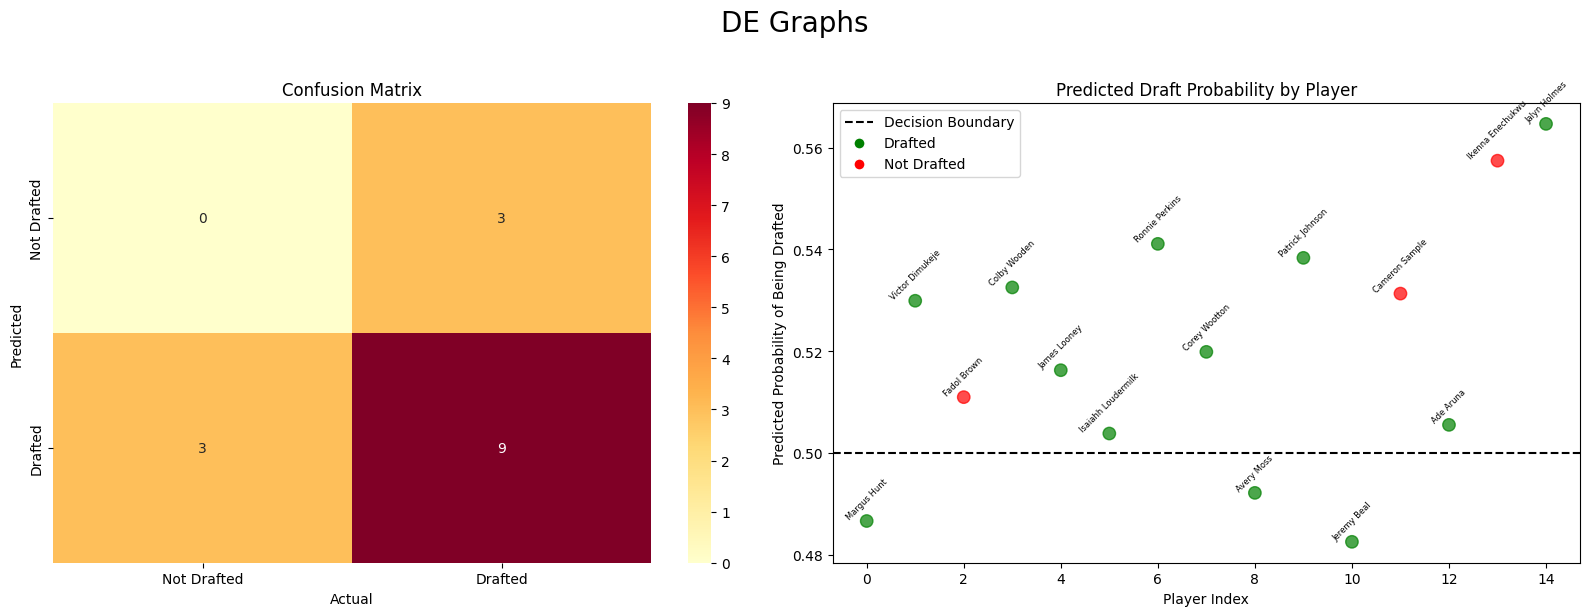

In [275]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DE Graphs', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

_, X_test_raw, _, y_test_raw, _, names_test = train_test_split(
    X_de, y_de, de_df["Player"].values, test_size=0.2, random_state=42
)

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    axes[1].annotate(name, (i, preds_flat[i]), fontsize=6, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()